In [3]:
# ЯЧЕЙКА 1. Импорты и путь к файлу

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

FILE_PATH = r"C:\Users\Ксения\Downloads\Тестовое_задание_Data_аналитик_ЦО_2025_.xlsx"
  # если ноутбук рядом с файлом
SHEET_NAME = "Данные для задачи 2"


In [5]:
# ЯЧЕЙКА 2. Загрузка данных (задача 2)

df_raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME)
df_raw.head(10)

,Дата,Код товара,Количество продано,Розничная цена,Цена с учётом скидки
0,2024-06-01,3226300004,9,271,271.0
1,2024-06-02,3226300004,15,271,271.0
2,2024-06-03,3226300004,12,271,216.8
3,2024-06-04,3226300004,17,271,216.8
4,2024-06-05,3226300004,13,271,216.8
5,2024-06-06,3226300004,18,271,216.8
6,2024-06-07,3226300004,7,271,271.0
7,2024-06-08,3226300004,9,271,271.0
8,2024-06-09,3226300004,12,271,271.0
9,2024-06-10,3226300004,6,271,271.0


In [6]:
# ЯЧЕЙКА 3. Приведение к “чистой” схеме колонок

df = df_raw.rename(columns={
    "Дата": "date",
    "Код товара": "sku",
    "Количество продано": "qty",
    "Розничная цена": "price_regular",
    "Цена с учётом скидки": "price_paid",
}).copy()

# типы
df["date"] = pd.to_datetime(df["date"])
df["sku"] = df["sku"].astype(str)  # удобнее как строка (не теряем ведущие нули, если бы были)
df["qty"] = pd.to_numeric(df["qty"], errors="coerce")
df["price_paid"] = pd.to_numeric(df["price_paid"], errors="coerce")
df["price_regular"] = pd.to_numeric(df["price_regular"], errors="coerce")

# полезные поля
df["weekday"] = df["date"].dt.dayofweek  # 0=Mon ... 6=Sun

df.head()


,date,sku,qty,price_regular,price_paid,weekday
0,2024-06-01,3226300004,9,271,271.0,5
1,2024-06-02,3226300004,15,271,271.0,6
2,2024-06-03,3226300004,12,271,216.8,0
3,2024-06-04,3226300004,17,271,216.8,1
4,2024-06-05,3226300004,13,271,216.8,2


In [7]:
# ЯЧЕЙКА 4. Гигиена: чистка + логарифмы

df = df.dropna(subset=["sku", "date", "qty", "price_paid"]).copy()
df = df[(df["qty"] > 0) & (df["price_paid"] > 0)].copy()

df["ln_qty"] = np.log(df["qty"].astype(float))
df["ln_price"] = np.log(df["price_paid"].astype(float))

print("Строк:", len(df))
print("SKU:", df["sku"].nunique())


Строк: 1220
SKU: 10


In [8]:
# ЯЧЕЙКА 5. Быстрая проверка вариативности цены по SKU (чтобы понимать, где вообще есть сигнал)

price_var = (
    df.groupby("sku")["price_paid"]
      .agg(n_obs="count", n_prices="nunique", mean="mean", std="std")
      .assign(cv=lambda x: x["std"] / x["mean"])
      .reset_index()
      .sort_values("sku")
)

price_var


,sku,n_obs,n_prices,mean,std,cv
0,14011400047,122,5,1525.786885,214.291172,0.140446
1,14012900005,122,5,1154.832787,143.290186,0.124079
2,15110900016,122,5,1415.960656,132.991835,0.093923
3,15111300006,122,6,7740.003279,772.087539,0.099753
4,15111300017,122,5,18728.268852,1459.804360,0.077947
5,19000000363,122,7,1970.731148,201.108555,0.102048
6,19000013047,122,5,2922.826230,401.393105,0.137330
7,19760336592,122,5,2695.973770,253.215015,0.093923
8,3226300004,122,6,260.232787,33.285121,0.127905
9,3234800007,122,7,330.685246,33.745664,0.102048


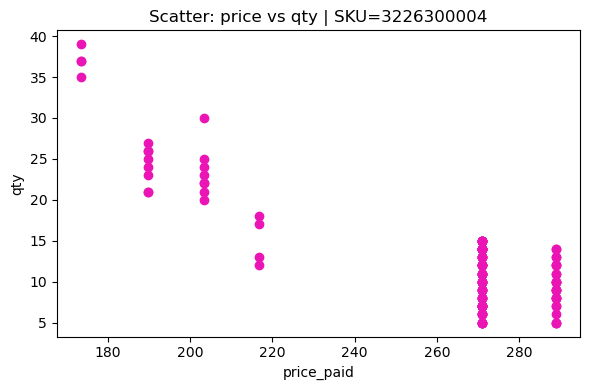

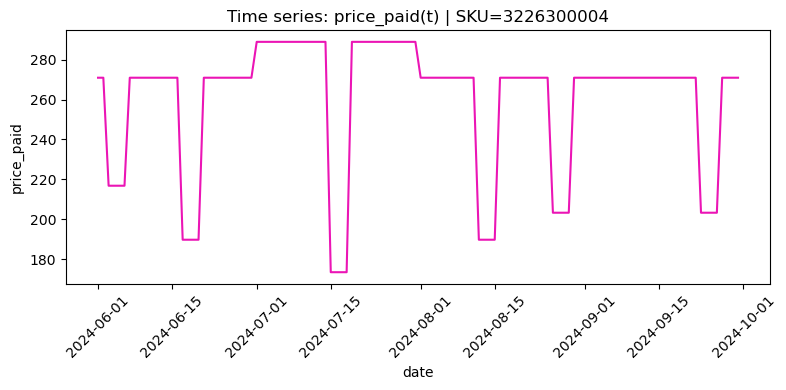

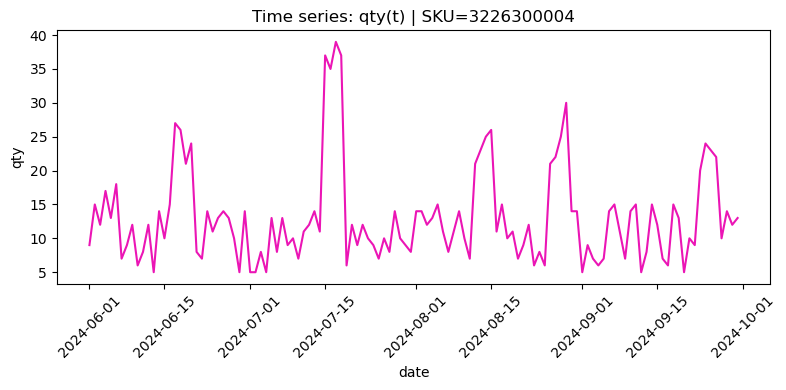

corr(price_paid, qty) = -0.857


In [10]:
# ЯЧЕЙКА 6 (обновлённая). EDA-графики для одного SKU

SKU_TO_PLOT = df["sku"].iloc[0]
g = df[df["sku"] == SKU_TO_PLOT].sort_values("date")

PINK = "#eb15b5"

# Scatter: price vs qty
plt.figure(figsize=(6, 4))
plt.scatter(g["price_paid"], g["qty"], color=PINK)
plt.xlabel("price_paid")
plt.ylabel("qty")
plt.title(f"Scatter: price vs qty | SKU={SKU_TO_PLOT}")
plt.tight_layout()
plt.show()

# Time series: price
plt.figure(figsize=(8, 4))
plt.plot(g["date"], g["price_paid"], color=PINK)
plt.xlabel("date")
plt.ylabel("price_paid")
plt.title(f"Time series: price_paid(t) | SKU={SKU_TO_PLOT}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Time series: qty
plt.figure(figsize=(8, 4))
plt.plot(g["date"], g["qty"], color=PINK)
plt.xlabel("date")
plt.ylabel("qty")
plt.title(f"Time series: qty(t) | SKU={SKU_TO_PLOT}")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("corr(price_paid, qty) =", round(g["price_paid"].corr(g["qty"]), 3))


In [11]:
# ЯЧЕЙКА 7. Функция оценки эластичности (log-log OLS + weekday dummies)

def fit_elasticity_ols_loglog(g: pd.DataFrame,
                             min_obs: int = 14,
                             min_unique_prices: int = 2,
                             min_cv_price: float = 0.005):
    """
    ln(qty) = a + b*ln(price_paid) + weekday_dummies + e
    b — ценовая эластичность спроса по цене (ожидаемо < 0)
    """
    n = len(g)
    uniq = int(g["price_paid"].nunique())
    mean_price = float(g["price_paid"].mean())
    cv = float(g["price_paid"].std() / mean_price) if mean_price != 0 else np.nan

    if n < min_obs:
        return None, {"status": "fail", "reason": "мало наблюдений", "n": n, "n_prices": uniq, "cv_price": cv}

    if uniq < min_unique_prices or (not np.isnan(cv) and cv < min_cv_price):
        return None, {"status": "fail", "reason": "нет вариативности цены", "n": n, "n_prices": uniq, "cv_price": cv}

    X = pd.get_dummies(g["weekday"], prefix="wd", drop_first=True).astype(float)
    X = pd.concat([g[["ln_price"]].astype(float), X], axis=1)
    X = sm.add_constant(X, has_constant="add")

    y = g["ln_qty"].astype(float)

    model = sm.OLS(y, X).fit()

    out = {
        "status": "ok",
        "n": n,
        "n_prices": uniq,
        "cv_price": cv,
        "b": float(model.params["ln_price"]),
        "p_value": float(model.pvalues["ln_price"]),
        "r2": float(model.rsquared),
    }
    return model, out


In [12]:
# ЯЧЕЙКА 8. Прогон по всем SKU → таблица эластичностей

models = {}
rows = []

for sku, g in df.groupby("sku"):
    g = g.sort_values("date")
    model, meta = fit_elasticity_ols_loglog(g)
    meta["sku"] = sku
    rows.append(meta)
    if model is not None:
        models[sku] = model

elasticity = pd.DataFrame(rows).sort_values("sku")
elasticity


,status,n,n_prices,cv_price,b,p_value,r2,sku
0,ok,122,5,0.140446,-2.760231,1.182596e-27,0.682925,14011400047
1,ok,122,5,0.124079,-3.145081,4.678709e-26,0.657127,14012900005
2,ok,122,5,0.093923,-2.484832,3.704647e-13,0.448796,15110900016
3,ok,122,6,0.099753,-3.206071,2.422319e-19,0.549962,15111300006
4,ok,122,5,0.077947,-4.124242,3.777055e-12,0.354348,15111300017
5,ok,122,7,0.102048,-2.646878,3.542044e-19,0.573068,19000000363
6,ok,122,5,0.137330,-2.836725,3.734112e-26,0.669023,19000013047
7,ok,122,5,0.093923,-2.404075,2.131669e-12,0.464476,19760336592
8,ok,122,6,0.127905,-2.738657,1.119441e-23,0.607069,3226300004
9,ok,122,7,0.102048,-2.735274,4.123678e-15,0.504018,3234800007


In [13]:
# ЯЧЕЙКА 9. Формула скидки для ×2 объёма + правила применимости

def discount_for_double_volume(b: float, cap: float = 0.70) -> float:
    """
    Q2/Q1 = (P2/P1)^b, нужно Q2/Q1=2
    => P2/P1 = 2^(1/b), скидка = 1 - P2/P1
    """
    if b is None or np.isnan(b) or b >= 0:
        return np.nan
    ratio = 2 ** (1 / b)   # P2/P1
    disc = 1 - ratio
    disc = float(disc)
    # здравый смысл: ограничим 0..cap
    disc = max(0.0, min(cap, disc))
    return disc

# критерии "можно рекомендовать": b<0 и коэффициент значим (например, p<0.05)
P_THRESHOLD = 0.05

elasticity["discount_x2"] = elasticity["b"].apply(discount_for_double_volume)
elasticity["recommendation_ok"] = (elasticity["status"].eq("ok")
                                  & (elasticity["b"] < 0)
                                  & (elasticity["p_value"] < P_THRESHOLD))

elasticity


,status,n,n_prices,cv_price,b,p_value,r2,sku,discount_x2,recommendation_ok
0,ok,122,5,0.140446,-2.760231,1.182596e-27,0.682925,14011400047,0.222070,True
1,ok,122,5,0.124079,-3.145081,4.678709e-26,0.657127,14012900005,0.197795,True
2,ok,122,5,0.093923,-2.484832,3.704647e-13,0.448796,15110900016,0.243423,True
3,ok,122,6,0.099753,-3.206071,2.422319e-19,0.549962,15111300006,0.194424,True
4,ok,122,5,0.077947,-4.124242,3.777055e-12,0.354348,15111300017,0.154702,True
5,ok,122,7,0.102048,-2.646878,3.542044e-19,0.573068,19000000363,0.230392,True
6,ok,122,5,0.137330,-2.836725,3.734112e-26,0.669023,19000013047,0.216785,True
7,ok,122,5,0.093923,-2.404075,2.131669e-12,0.464476,19760336592,0.250480,True
8,ok,122,6,0.127905,-2.738657,1.119441e-23,0.607069,3226300004,0.223608,True
9,ok,122,7,0.102048,-2.735274,4.123678e-15,0.504018,3234800007,0.223851,True


In [14]:
# ЯЧЕЙКА 10. Базовые цены (медианы) + финальная таблица результата

base_prices = (
    df.groupby("sku")
      .agg(base_price_paid=("price_paid", "median"),
           base_price_regular=("price_regular", "median"))
      .reset_index()
)

final = (
    base_prices.merge(elasticity, on="sku", how="left")
)

def make_comment(row):
    if row["status"] != "ok":
        return row.get("reason", "не удалось оценить")
    if not row["recommendation_ok"]:
        # статус ok, но коэффициент не подходит по критериям
        if row["b"] >= 0:
            return "b >= 0: вероятна путаница факторов (промо/сезонность/ассортимент), рекомендован тест 10–20%"
        if row["p_value"] >= P_THRESHOLD:
            return "коэффициент незначим: рекомендован тест 10–20%"
        return "не выполнены критерии применимости, рекомендован тест 10–20%"
    return "рекомендация применима (b<0, значим)"

final["comment"] = final.apply(make_comment, axis=1)

# приводим скидку к % для читабельности
final["discount_x2_pct"] = (final["discount_x2"] * 100).round(1)

final_out = final[[
    "sku",
    "base_price_regular",
    "base_price_paid",
    "b",
    "p_value",
    "r2",
    "discount_x2_pct",
    "comment",
]].sort_values("sku")

final_out


,sku,base_price_regular,base_price_paid,b,p_value,r2,discount_x2_pct,comment
0,14011400047,1630.0,1630.0,-2.760231,1.182596e-27,0.682925,22.2,"рекомендация применима (b<0, значим)"
1,14012900005,1223.0,1223.0,-3.145081,4.678709e-26,0.657127,19.8,"рекомендация применима (b<0, значим)"
2,15110900016,1479.0,1479.0,-2.484832,3.704647e-13,0.448796,24.3,"рекомендация применима (b<0, значим)"
3,15111300006,8057.0,8057.0,-3.206071,2.422319e-19,0.549962,19.4,"рекомендация применима (b<0, значим)"
4,15111300017,19396.0,19396.0,-4.124242,3.777055e-12,0.354348,15.5,"рекомендация применима (b<0, значим)"
5,19000000363,2062.0,2062.0,-2.646878,3.542044e-19,0.573068,23.0,"рекомендация применима (b<0, значим)"
6,19000013047,3117.0,3117.0,-2.836725,3.734112e-26,0.669023,21.7,"рекомендация применима (b<0, значим)"
7,19760336592,2816.0,2816.0,-2.404075,2.131669e-12,0.464476,25.0,"рекомендация применима (b<0, значим)"
8,3226300004,271.0,271.0,-2.738657,1.119441e-23,0.607069,22.4,"рекомендация применима (b<0, значим)"
9,3234800007,346.0,346.0,-2.735274,4.123678e-15,0.504018,22.4,"рекомендация применима (b<0, значим)"


In [15]:
# ЯЧЕЙКА 11. (Опционально) Сохранить результат в Excel

OUTPUT_PATH = "task2_elasticity_result.xlsx"
final_out.to_excel(OUTPUT_PATH, index=False)
OUTPUT_PATH


'task2_elasticity_result.xlsx'

In [16]:
# ЯЧЕЙКА 12. Короткий текстовый вывод (ограничения / допущения)

notes = [
    "Модель: ln(qty) = a + b*ln(price_paid) + weekday_dummies + e; b интерпретируется как ценовая эластичность.",
    "Если цена почти не меняется, эластичность по историческим данным не идентифицируется.",
    "Модель не контролирует промо-механики/наличие товара/маркетинг/конкурентов; b — оценка при допущении прочих равных в среднем.",
    "Скидка для ×2 рассчитана из степенной зависимости; введён cap (по умолчанию 70%) для защиты от абсурдных значений.",
    f"Критерий применимости рекомендации: b<0 и p-value<{P_THRESHOLD}.",
]

for s in notes:
    print("-", s)


- Модель: ln(qty) = a + b*ln(price_paid) + weekday_dummies + e; b интерпретируется как ценовая эластичность.
- Если цена почти не меняется, эластичность по историческим данным не идентифицируется.
- Модель не контролирует промо-механики/наличие товара/маркетинг/конкурентов; b — оценка при допущении прочих равных в среднем.
- Скидка для ×2 рассчитана из степенной зависимости; введён cap (по умолчанию 70%) для защиты от абсурдных значений.
- Критерий применимости рекомендации: b<0 и p-value<0.05.
